In [2]:
import torch
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
from torch.utils.data import Dataset, DataLoader

def sex_transform(sex: str):
    return 0 if sex == 'F' else 1

class PairedECGDataset(Dataset):

    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        ecg_0 = self.data[index][0]
        ecg_1 = self.data[index][1]

        return ecg_0, ecg_1

In [3]:
# paired_dataset = torch.load("paired_Mimic_vae_mix_nomic_test.pt")
# paired_dataset = torch.load("paired_Mimic_vae_multi_nomic_test.pt")
paired_dataset = torch.load("paired_Mimic_vae_multi_nomic.pt")
len(paired_dataset)

6408782

## Reference Data Selection

In [10]:
index = 0
visited_sex = []
for pair_ecg in paired_dataset:
    ref_text = pair_ecg[0]['label']['text']
    # if ref_text.lower() != "sinus rhythm|normal ecg":
    #     continue
    if "pvc" not in ref_text.lower() or len(ref_text.split('|')) > 2:
        continue
    if pair_ecg[0]['label']['sex'] in visited_sex:
        continue
    index += 1
    
    print(pair_ecg[0]['label'])
    torch.save(pair_ecg[0], f'prepared_input/pvc_{index}.pt')
    visited_sex.append(pair_ecg[0]['label']['sex'])
    if index == 2:
        break

{'text': 'Sinus bradycardia with PVC(s)|Normal ECG except for rate', 'subject_id': 10001843, 'hr': 53.691275167785236, 'ecg_time': '2131-11-09 13:20:00', 'sex': 'M', 'age': 73, 'text_embed': tensor([[ 0.0744,  0.0404, -0.1720,  ..., -0.0480, -0.0398, -0.0015],
        [ 0.0475,  0.0404, -0.1714,  ..., -0.0563, -0.0321,  0.0014]])}
{'text': 'Atrial flutter with PVC(s)|Abnormal ECG', 'subject_id': 10002930, 'hr': 93.00265721877768, 'ecg_time': '2197-04-07 08:27:00', 'sex': 'F', 'age': 52, 'text_embed': tensor([[ 0.0707,  0.0842, -0.1736,  ..., -0.0043, -0.0257,  0.0093],
        [ 0.0393,  0.0343, -0.1885,  ..., -0.0466, -0.0267,  0.0287]])}


## Memory analysis

In [6]:
import numpy as np

def pad_text_embed(embed_list):
    lengths = [e.shape[0] for e in embed_list]
    max_len = max(lengths)
    embed_dim = embed_list[0].shape[1]

    padded_embeds = []
    masks = []

    for embed in embed_list:
        pad_len = max_len - embed.shape[0]
        padded = torch.cat([embed, torch.zeros(pad_len, embed_dim)], dim=0)
        mask = torch.cat([torch.ones(embed.shape[0]), torch.zeros(pad_len)])
        padded_embeds.append(padded)
        masks.append(mask)

    return torch.stack(padded_embeds), torch.stack(masks)

def paired_ecg_collate_fn(batch):
    ecg0_list, ecg1_list = zip(*batch)  # unzip
    ecg0 = {}
    ecg1 = {}

    ecg0['data'] = torch.stack([ecg['data'] for ecg in ecg0_list])
    ecg1['data'] = torch.stack([ecg['data'] for ecg in ecg1_list])

    ecg0['label'] = {}
    ecg1['label'] = {}
    for key, value in ecg0_list[0]['label'].items():
        if key in ['text_embed', 'text_embed_mask']:
            continue

        key_type = type(value)
        if key_type in (float, int, np.float64):
            ecg0['label'][key] = torch.tensor([ecg['label'][key] for ecg in ecg0_list])
            ecg1['label'][key] = torch.tensor([ecg['label'][key] for ecg in ecg1_list])
    
        elif key == 'sex':
            ecg0['label'][key] = torch.tensor([sex_transform(ecg['label'][key]) for ecg in ecg0_list])
            ecg1['label'][key] = torch.tensor([sex_transform(ecg['label'][key]) for ecg in ecg1_list])

        elif key == 'text_embed_whole':
            ecg0['label'][key] = torch.tensor([ecg['label'][key] for ecg in ecg0_list])
            ecg1['label'][key] = torch.tensor([ecg['label'][key] for ecg in ecg1_list])
        
        else:
            ecg0['label'][key] = [ecg['label'][key] for ecg in ecg0_list]
            ecg1['label'][key] = [ecg['label'][key] for ecg in ecg1_list]
        

    ecg0_embed_list = [ecg['label']['text_embed'] for ecg in ecg0_list]
    ecg1_embed_list = [ecg['label']['text_embed'] for ecg in ecg1_list]

    ecg0_embed, ecg0_mask = pad_text_embed(ecg0_embed_list)
    ecg1_embed, ecg1_mask = pad_text_embed(ecg1_embed_list)

    ecg0['label'].update({
        'text_embed': ecg0_embed,
        'text_embed_mask': ecg0_mask
    })
    ecg1['label'].update({
        'text_embed': ecg1_embed,
        'text_embed_mask': ecg1_mask
    })
    return (ecg0, ecg1)

In [96]:
dataloader = DataLoader(paired_dataset, 1, collate_fn=paired_ecg_collate_fn)

In [ ]:
import tqdm
for ecg0, ecg1 in tqdm.tqdm(dataloader):
    print(ecg0['data'].shape)
    for key, value in ecg0['label'].items():
        if hasattr(value, 'shape'):
            print(key, value.shape)
        else:
            print(key, value)
    print(ecg0['label']['text_embed_mask'])
    # print(ecg0['label'])
    break

  0%|          | 0/399499 [00:00<?, ?it/s]

torch.Size([1, 4, 128])
text ['Sinus rhythm|Possible right atrial abnormality|Borderline ECG']
subject_id [10000032]
hr torch.Size([1])
ecg_time ['2180-07-23 08:44:00']
sex torch.Size([1])
age torch.Size([1])
text_embed_whole torch.Size([1, 768])
text_embed torch.Size([1, 3, 768])
text_embed_mask torch.Size([1, 3])
tensor([[1., 1., 1.]])
{'text': ['Sinus rhythm|Possible right atrial abnormality|Borderline ECG'], 'subject_id': [10000032], 'hr': tensor([90.9682], dtype=torch.float64), 'ecg_time': ['2180-07-23 08:44:00'], 'sex': tensor([0]), 'age': tensor([52]), 'text_embed_whole': tensor([[ 9.2525e-02,  1.7881e-02, -1.8701e-01,  1.8142e-02,  4.9149e-02,
         -3.1547e-02,  5.0642e-02, -9.9741e-03,  2.6008e-02, -4.4532e-02,
          2.8976e-02,  9.1519e-02,  4.4852e-02,  2.1015e-02, -4.4962e-02,
         -5.1175e-02,  1.1643e-02, -2.4434e-02,  2.0514e-02, -2.9881e-02,
         -2.5044e-02,  2.1037e-02, -5.9137e-02,  2.6959e-02,  7.3089e-02,
          5.0195e-02, -9.9536e-04,  1.3808e-

In [5]:
len(paired_dataset)

399499

In [4]:
paired_dataset[0][0]['label']['text_embed'] is paired_dataset[1][0]['label']['text_embed']

True

In [5]:
print(paired_dataset[0][0] is paired_dataset[1][0])
print(paired_dataset[0][0]['label'] is paired_dataset[1][0]['label'])
print(paired_dataset[0][0]['label']['text_embed'] is paired_dataset[1][0]['label']['text_embed'])

True
True
True


In [6]:
paired_dataset[1][0]['label']['ecg_time'] = "1"

In [88]:
paired_dataset.data[1][0]['label']

{'text': 'Sinus rhythm|Possible right atrial abnormality|Borderline ECG',
 'subject_id': 10000032,
 'hr': 90.96816114359976,
 'ecg_time': '2180-07-23 08:44:00',
 'sex': 'F',
 'age': 52,
 'text_embed': tensor([[ 0.0496,  0.0138, -0.1832,  ..., -0.0567, -0.0357,  0.0113],
         [ 0.0462,  0.0183, -0.1677,  ..., -0.0359, -0.0479,  0.0403],
         [ 0.0762,  0.0446, -0.1726,  ..., -0.0089, -0.0329,  0.0344]]),
 'text_embed_whole': [0.09252516180276871,
  0.017881158739328384,
  -0.1870097815990448,
  0.018142294138669968,
  0.049149032682180405,
  -0.03154725581407547,
  0.0506422184407711,
  -0.009974131360650063,
  0.026008108630776405,
  -0.0445316918194294,
  0.028976185247302055,
  0.09151946753263474,
  0.04485158249735832,
  0.021014761179685593,
  -0.044961776584386826,
  -0.051175396889448166,
  0.01164320483803749,
  -0.024433987215161324,
  0.02051364816725254,
  -0.029880892485380173,
  -0.025044260546565056,
  0.02103741466999054,
  -0.05913691967725754,
  0.0269589368253

In [7]:
from torch.utils.data import DataLoader
import psutil
import os
import time

def print_memory(prefix=""):
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    print(f"{prefix} | RSS: {mem_info.rss / 1024**2:.2f} MB | VMS: {mem_info.vms / 1024**2:.2f} MB")

def main():
    print_memory("Initial")

    dataset = PairedECGDataset("paired_Mimic_vae_mix_nomic_test.pt")
    print_memory("Dataset loaded (Not access data yet)")

    _ = dataset[0]
    print_memory("After triggering __getitem__")

    loader = DataLoader(dataset, batch_size=512, num_workers=0, shuffle=False, collate_fn=paired_ecg_collate_fn)

    print("wait 2s before starting...")
    time.sleep(2)

    print(len(loader))
    for epoch in [1, 2]:
        print(f"Epoch: {epoch}")
        for i, (ecg_0, ecg_1) in enumerate(loader):
            if i % 100 == 0:
                print_memory(f"Iteration batch {i}")

main()

Initial | RSS: 4151.13 MB | VMS: 7802.89 MB
Dataset loaded (Not access data yet) | RSS: 6214.27 MB | VMS: 9867.70 MB
After triggering __getitem__ | RSS: 6214.27 MB | VMS: 9867.70 MB
wait 2s before starting...
781
Epoch: 1
Iteration batch 0 | RSS: 6241.22 MB | VMS: 9891.82 MB
Iteration batch 100 | RSS: 6277.18 MB | VMS: 9928.02 MB
Iteration batch 200 | RSS: 6276.70 MB | VMS: 9927.82 MB
Iteration batch 300 | RSS: 6265.50 MB | VMS: 9917.32 MB
Iteration batch 400 | RSS: 6257.81 MB | VMS: 9909.82 MB
Iteration batch 500 | RSS: 6277.06 MB | VMS: 9929.32 MB
Iteration batch 600 | RSS: 6274.06 MB | VMS: 9926.32 MB
Iteration batch 700 | RSS: 6278.14 MB | VMS: 9930.38 MB
Epoch: 2
Iteration batch 0 | RSS: 6251.54 MB | VMS: 9903.90 MB
Iteration batch 100 | RSS: 6287.67 MB | VMS: 9939.91 MB
Iteration batch 200 | RSS: 6275.55 MB | VMS: 9927.82 MB
Iteration batch 300 | RSS: 6264.77 MB | VMS: 9917.32 MB
Iteration batch 400 | RSS: 6272.32 MB | VMS: 9924.82 MB
Iteration batch 500 | RSS: 6251.38 MB | VMS: 

In [ ]:
import tqdm
cnt = 0
for ecg_ref, ecg_tar in tqdm.tqdm(paired_dataset):
    # assert ecg_ref['label']['sex'] == ecg_tar['label']['sex']
        # print(ecg_ref['label']['subject_id'])
    # if ecg_ref['label']['sex'] == 'F':
    #     cnt += 1
    pass
# print(cnt)

  2%|▏         | 8376/399499 [00:24<12:24, 525.23it/s]

## Statistics analysis

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset

def sex_transform(sex: str):
    return 0 if sex == 'F' else 1

class ListDataset(Dataset):
    def __init__(self, path:str):
        self.data= torch.load(path)

    def __len__(self):
        return len(self.data) 
    
    def __getitem__(self, idx):
        latent_dict = self.data[idx] 

        return latent_dict['data'], latent_dict['label']


In [3]:
# Dataset statistics:
dataset = ListDataset("Mimic_vae.pt")

In [6]:
hr = []
age = []
for data, label in dataset:
    hr.append(label['hr'])
    age.append(label['age'])

hr = torch.tensor(hr)
age = torch.tensor(age, dtype=torch.float32)
print(f"HR mean: {hr.mean()} std: {hr.std()}")
print(f"AGE mean: {age.mean()} std: {age.std()}")

HR mean: 77.95864676508116 std: 20.370966669845814
AGE mean: 64.25709533691406 std: 17.137723922729492


In [ ]:
dataset = ListDataset("Mimic_vae_multi_nomic.pt")
# dataset = ListDataset("Mimic_vae_nomic.pt")

In [5]:
len(dataset)

744372

In [4]:
max_length = 0
for X, y in dataset:
    if y['text_embed'].shape[0] > max_length:
        max_length = y['text_embed'].shape[0]

max_length

17

In [9]:
dataset[0][1]['text_embed'].shape, dataset[0][1]['text_embed_mask'].shape

(torch.Size([18, 768]), torch.Size([18]))

In [10]:
dataloader = DataLoader(dataset, batch_size=16)
for X, y in dataloader:
    embed = y['text_embed']
    print(embed.shape)
    break

torch.Size([16, 18, 768])


In [ ]:
from collections import defaultdict
from tqdm import tqdm
import torch

test = '_test'
dataset = torch.load(f"./Mimic_vae_multi_nomic{test}.pt")
grouped_dataset = defaultdict(list)

# grouping
for entry in tqdm(dataset):
    id = entry['label']['subject_id']
    grouped_dataset[id].append(entry)
print(f"number of patient: {len(grouped_dataset)}")


100%|██████████| 50000/50000 [00:00<00:00, 1628817.97it/s]

number of patient: 10229


In [6]:
patient_list = []
for key, value in grouped_dataset.items():
    if len(value) > 100:
        patient_list.append(key)
print(len(patient_list))

5


In [7]:
patient_list

[10108435, 10213338, 10577647, 10578325, 10580201]

In [10]:
grouped_dataset[10108435][0]['label']

{'text': 'Sinus bradycardia|Leftward axis|Borderline ECG',
 'subject_id': 10108435,
 'hr': 57.2276388300127,
 'ecg_time': '2183-08-10 09:14:00',
 'sex': 'M',
 'age': 62,
 'text_embed': tensor([[ 0.0709,  0.0311, -0.1740,  ..., -0.0455, -0.0322,  0.0172],
         [ 0.0181, -0.0027, -0.0948,  ..., -0.0467, -0.0546,  0.0191],
         [ 0.0762,  0.0446, -0.1726,  ..., -0.0089, -0.0329,  0.0344]])}

In [1]:
import torch
dataset_path = "../data/Mimic_vae.pt"
dataset = torch.load(dataset_path)

In [2]:
from collections import defaultdict
grouped_dataset = defaultdict(list)
# grouping
for entry in dataset:
    id = entry['label']['subject_id']
    grouped_dataset[id].append(entry)

In [ ]:
# 10229 + 149354
len(grouped_dataset)

149354

In [1]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

mimic_dataset = torch.load('Mimic_vae_test.pt')
len(mimic_dataset)

50000

In [2]:
grouped_dataset = defaultdict(list)
# grouping
for entry in mimic_dataset:
    id = entry['label']['subject_id']
    grouped_dataset[id].append(entry)

dataset_cnt = defaultdict(int)
for ecg_list in grouped_dataset.values():
    dataset_cnt[len(ecg_list)] += 1

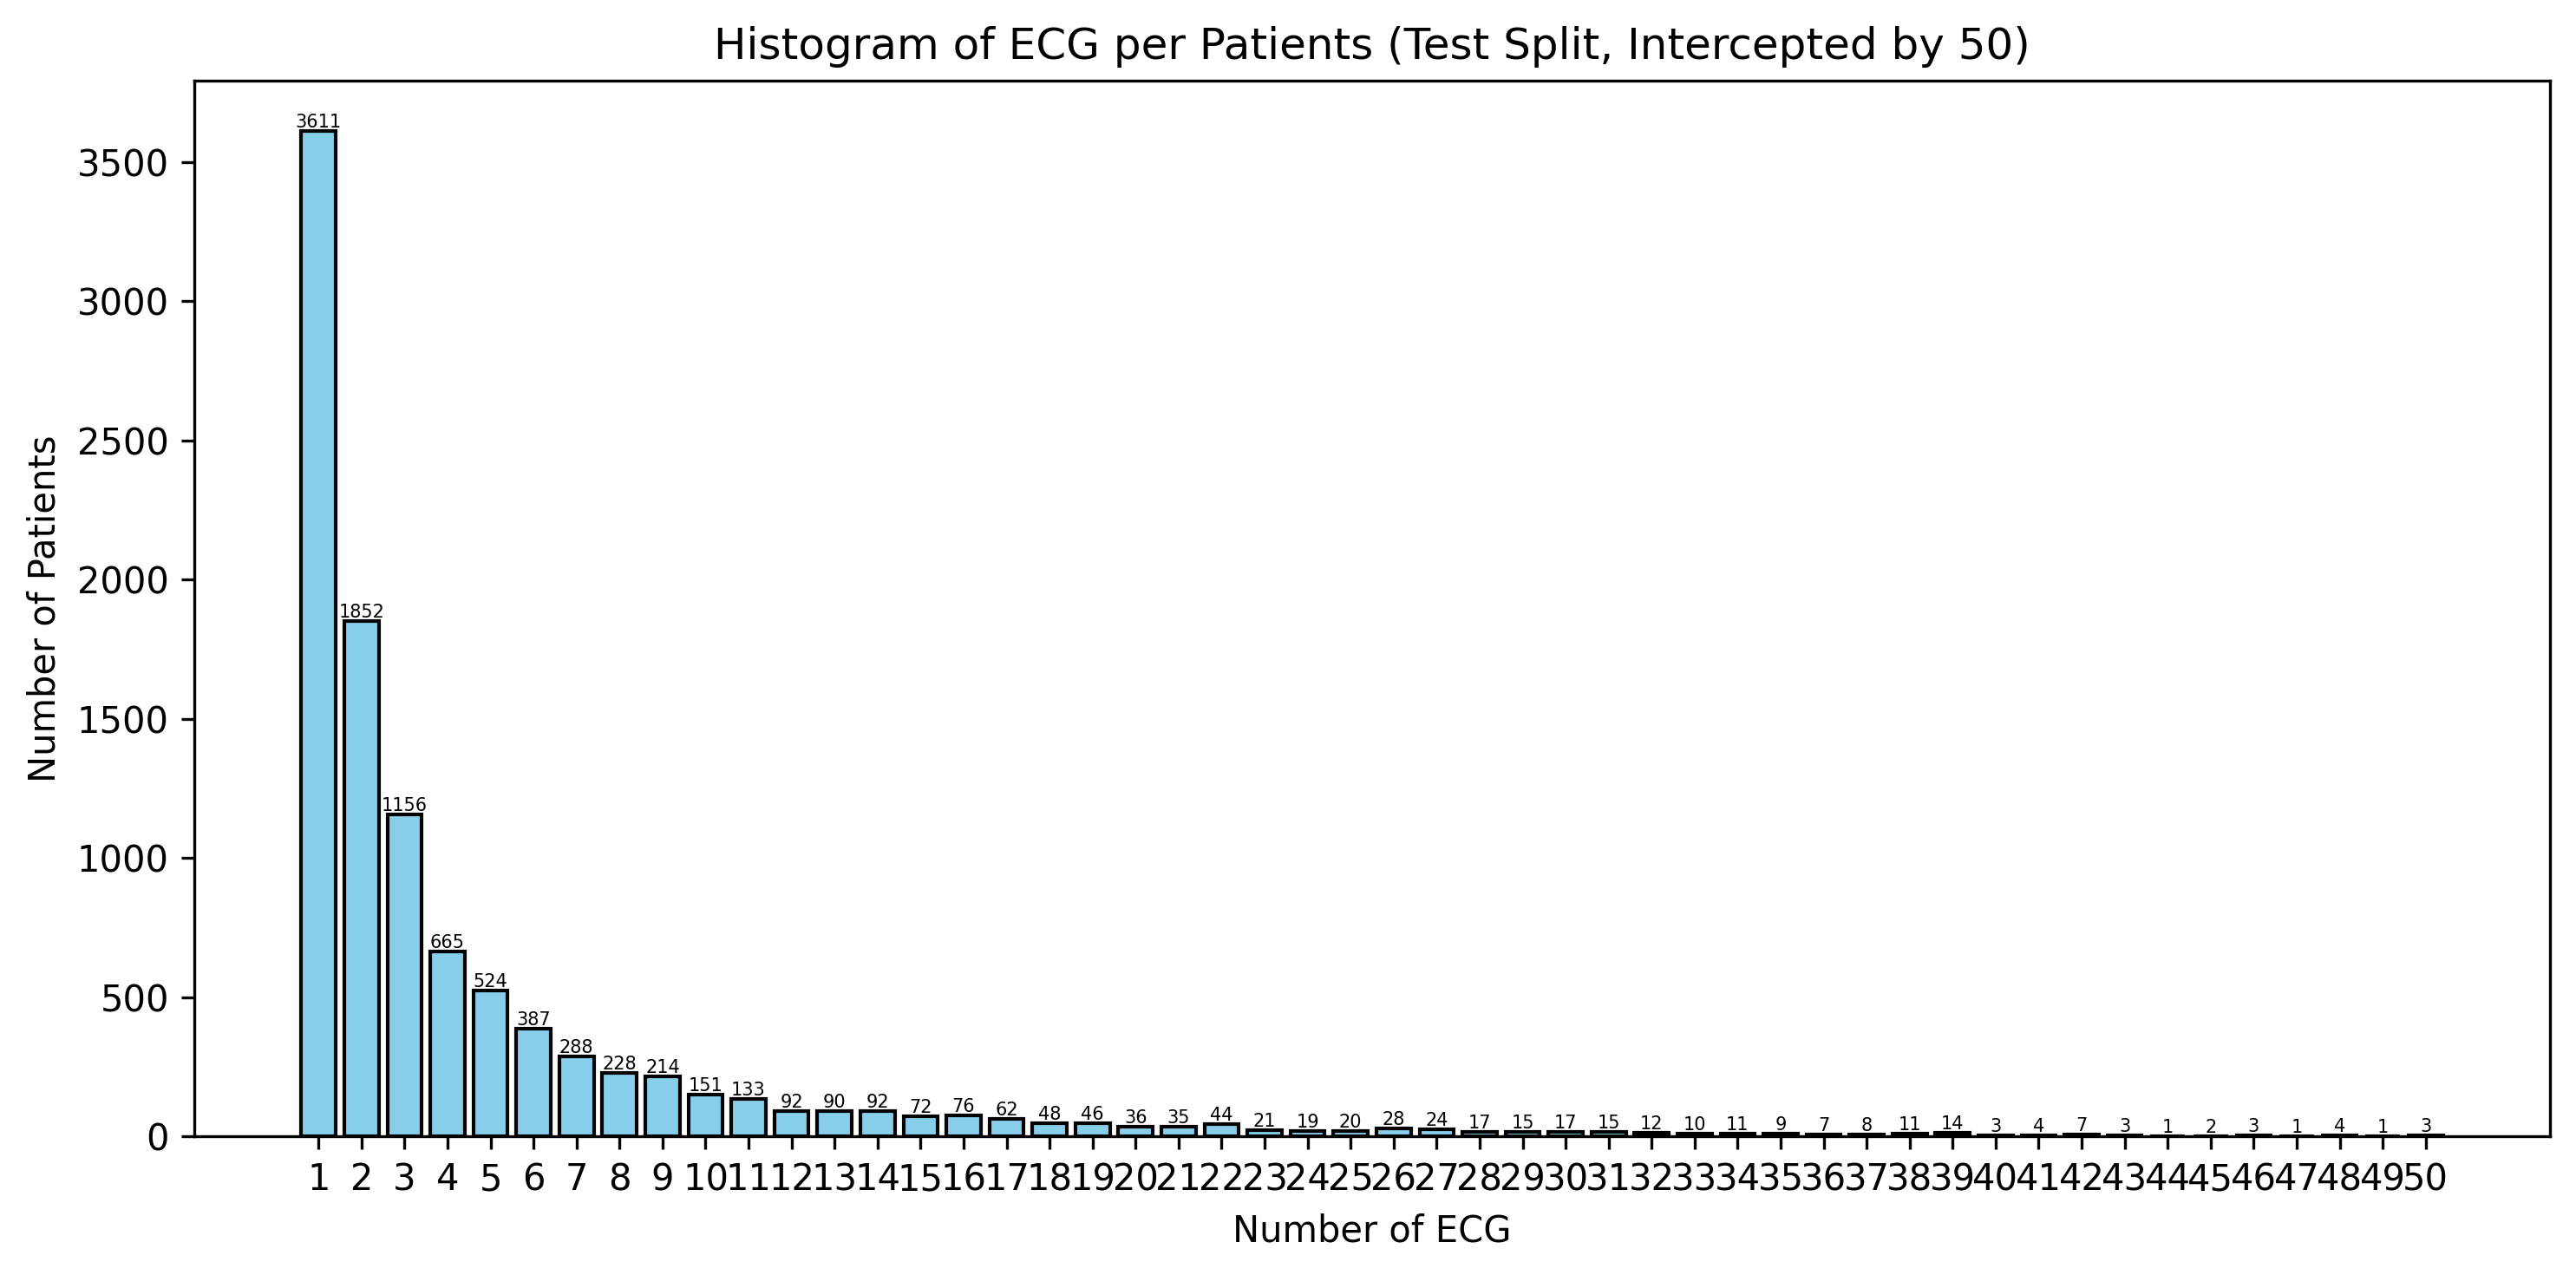

In [3]:
# Plot histogram
# Add labels on top of each bar
plt.figure(figsize=(10, 5), dpi=300)
upper_bound = 51
bars = plt.bar(list(range(1, upper_bound)), [dataset_cnt[x] for x in range(1, upper_bound)], color='skyblue', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, str(yval),
             ha='center', va='bottom', fontsize=5)
plt.xlabel("Number of ECG")
plt.ylabel("Number of Patients")
# plt.title("Histogram of ECG per Patients (Training Split, Intercepted by 50)")
plt.title("Histogram of ECG per Patients (Test Split, Intercepted by 50)")
plt.xticks(list(range(1,upper_bound)))
plt.tight_layout()
# plt.savefig('../figure/dataset/mimic_train_hist.pdf')
plt.savefig('../figure/dataset/mimic_test_hist.pdf')
plt.show()

In [4]:
ecg_num, subject_num = list(dataset_cnt.keys()), list(dataset_cnt.values())
avg_ecg_per_person = len(mimic_dataset) / sum(subject_num)
avg_ecg_per_person_2 = (len(mimic_dataset) - dataset_cnt[1]) / (sum(dataset_cnt.values()) - dataset_cnt[1])
max_ecg_per_person = max(dataset_cnt.keys())
print(f"{avg_ecg_per_person:.2f}, {avg_ecg_per_person_2:.2f}, {max_ecg_per_person}")

4.89, 7.01, 168


## PTBXL

In [1]:
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

ptb_dataset = torch.load('PTBXL_vae_test.pt')

In [3]:
ptb_dataset[0]['label']

{'text': 'The report of the ECG is that sinusrhythmus periphere niederspannung|diagnostic: normal ECG|form: low QRS voltages in the frontal and horizontal leads|rhythm: sinus rhythm|',
 'age': 56.0,
 'gender': 'F',
 'subject_id': 15709,
 'ecg_time': '1984-11-09 09:17:34',
 'hr': 63.911376224968045}

In [2]:
grouped_dataset = defaultdict(list)
# grouping
for entry in ptb_dataset:
    id = entry['label']['subject_id']
    grouped_dataset[id].append(entry)

In [3]:
dataset_cnt = defaultdict(int)
for ecg_list in grouped_dataset.values():
    dataset_cnt[len(ecg_list)] += 1

In [4]:
len(ptb_dataset)

21799

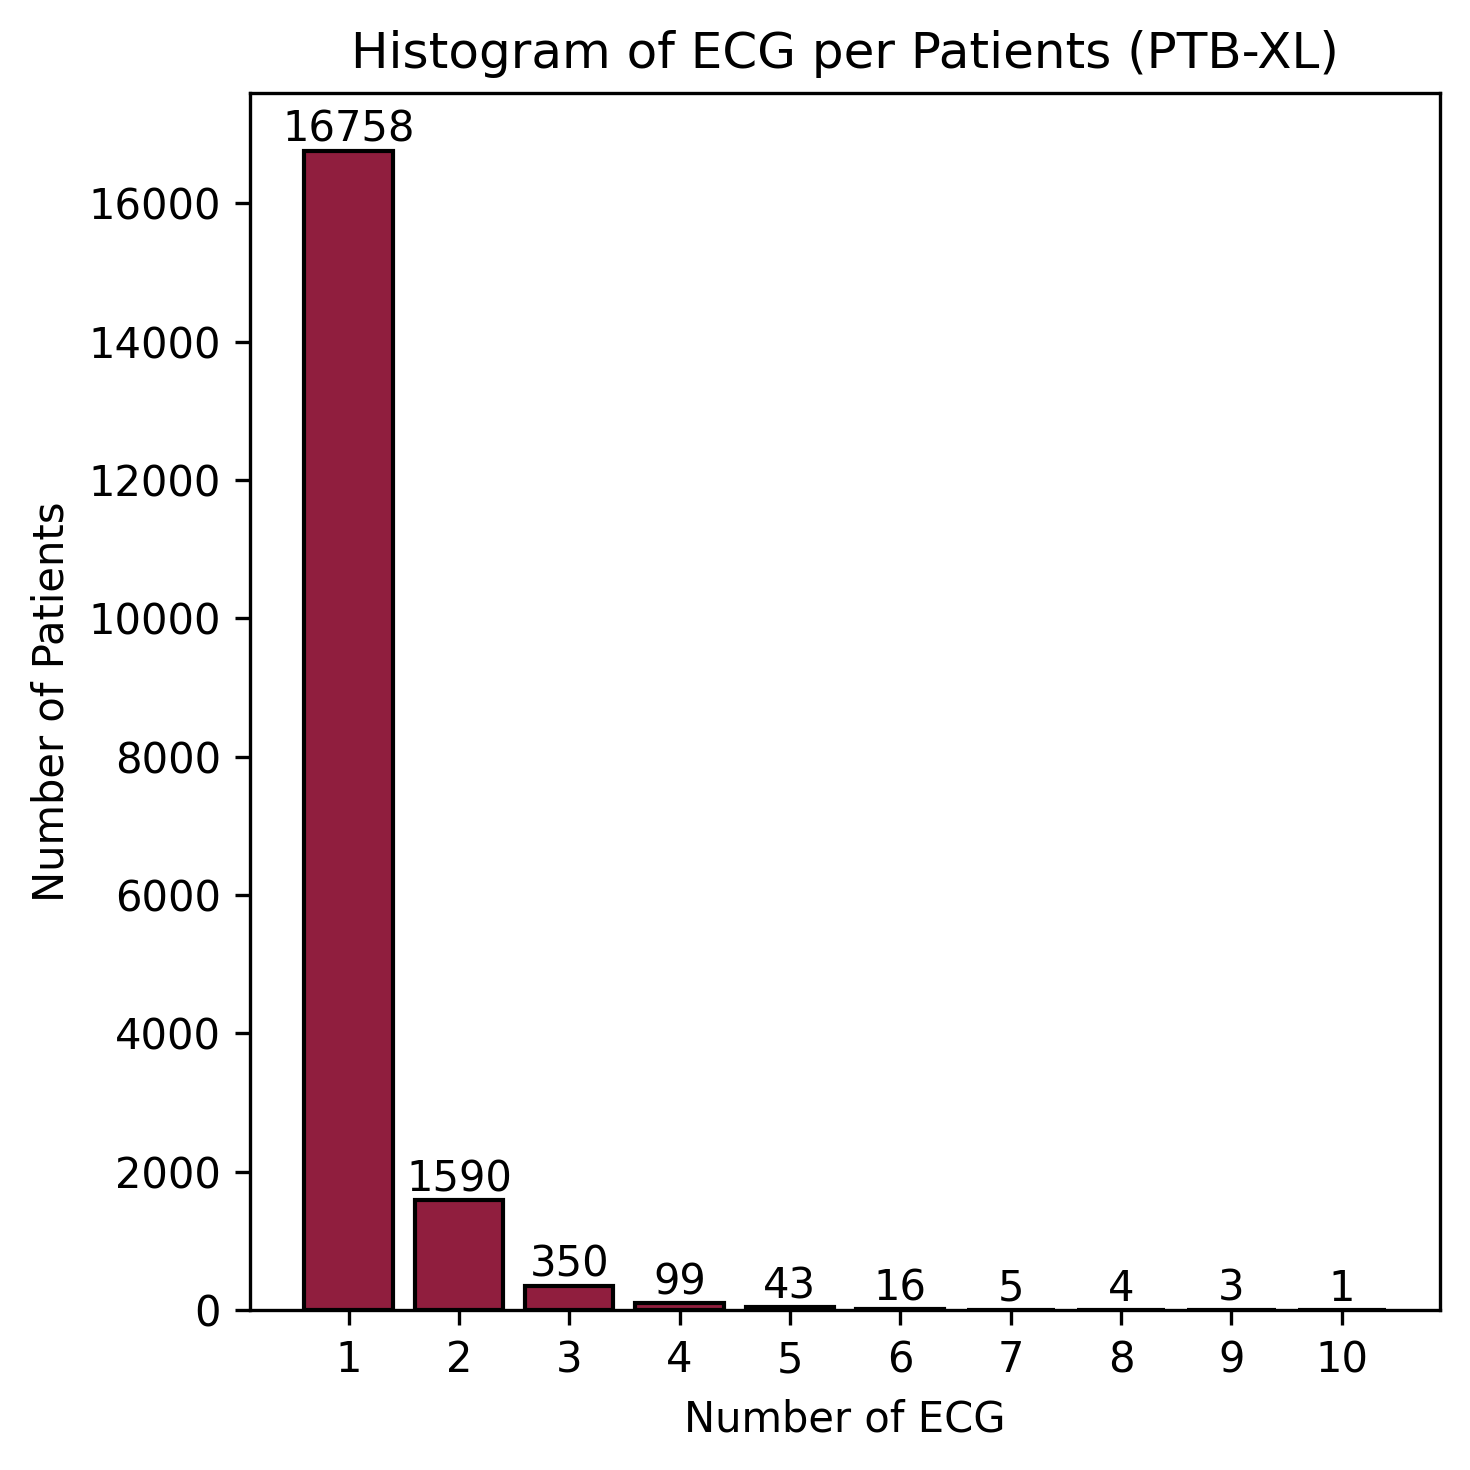

In [5]:
subject_num, counts = list(dataset_cnt.keys()), list(dataset_cnt.values())
# Plot histogram
# Add labels on top of each bar
plt.figure(figsize=(5, 5), dpi=300)
bars = plt.bar(subject_num[:], counts[:], color='#901E3E', edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, str(yval),
             ha='center', va='bottom', fontsize=10)
plt.xlabel("Number of ECG")
plt.ylabel("Number of Patients")
plt.title("Histogram of ECG per Patients (PTB-XL)")
plt.xticks(subject_num[:])
plt.tight_layout()
plt.savefig('../figure/dataset/ptbxl_test_hist.pdf')
plt.show()

In [11]:
ecg_num, subject_num = list(dataset_cnt.keys()), list(dataset_cnt.values())
avg_ecg_per_person = len(ptb_dataset) / sum(subject_num)
avg_ecg_per_person_2 = (len(ptb_dataset) - dataset_cnt[1]) / (sum(dataset_cnt.values()) - dataset_cnt[1])
max_ecg_per_person = max(dataset_cnt.keys())
print(f"{avg_ecg_per_person:.2f}, {avg_ecg_per_person_2:.2f}, {max_ecg_per_person}")

1.16, 2.39, 10


In [16]:
paired_ptbxl = torch.load("paired_PTBXL_vae_mix_nomic_test.pt")
len(paired_ptbxl)

4269